### Configure project root

In [2]:
# connect to project root for imports

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [29]:
# Standard imports

import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from src.data_loader import load_mnist
from src.models import MNISTModel
from src.models import CNNModel

# Reload multilevel module to pick up recent changes
import importlib
import src.multilevel
importlib.reload(src.multilevel)

from src.multilevel import train_mnist_single_level, train_mnist_multilevel

# Import optimization runner
import src.optimization
importlib.reload(src.optimization)
from src.optimization import run_mnist_experiment

# Fixed seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make PyTorch more reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Mnist folder directory

In [31]:
# MNIST notebook paths

from pathlib import Path

# Base project directory
project_root = Path("..")

#  DATA DIRECTORIES
data_dir = project_root / "data"
mnist_data_dir = data_dir / "mnist"

# FIGURE DIRECTORIES
figures_dir = project_root / "figures"

mnist_fig_dir = figures_dir / "mnist"
comparison_fig_dir = figures_dir / "comparison"

# RESULTS DIRECTORIES
results_dir = project_root / "results"

mnist_results_dir = results_dir / "mnist"
comparison_results_dir = results_dir / "comparison"

# Create folders if they do not exist
for folder in [
    mnist_data_dir,
    comparison_fig_dir,
    mnist_results_dir,
    comparison_results_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

print("MNIST data path:", mnist_data_dir.resolve());

MNIST data path: C:\Users\edwin\Desktop\PSU_Academics\MTH_563_Computational_Method_DS\computatinal_ml_project\data\mnist


## 1. Data loaded as mini-batches

In [32]:
# Load MNIST data
train_loader, test_loader = load_mnist()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Get one batch of data
images, labels = next(iter(train_loader))

# Move sample batch to device only if needed later
images = images.to(device)
labels = labels.to(device)

# Check tensor shapes
print("Batch shape (images):", images.shape)
print("Batch shape (labels):", labels.shape)

# Check pixel value range
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

# Check dataset sizes
print("Train size:", len(train_loader.dataset))
print("Test size:", len(test_loader.dataset))

# Check number of batches
print("Number of train batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

# Check batch size
print("Batch size:", images.shape[0])

# Preview labels
print("Sample labels:", labels[:10].cpu().tolist())

# Unique labels in current batch
print("Unique labels in batch:", torch.unique(labels).cpu())

print("\nMNIST data loading and validation checks complete")

Using device: cpu
Batch shape (images): torch.Size([128, 1, 28, 28])
Batch shape (labels): torch.Size([128])
Min pixel value: -1.0
Max pixel value: 1.0
Train size: 60000
Test size: 10000
Number of train batches: 469
Number of test batches: 79
Batch size: 128
Sample labels: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]
Unique labels in batch: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

MNIST data loading and validation checks complete


#### Data Summary

The MNIST dataset was successfully loaded and validated for model training and evaluation. The data consists of grayscale images with shape 28×28, organized into batches of 128 samples, resulting in tensor dimensions of [128,1,28,28] for images and [128] for corresponding labels. Pixel values are normalized within the range [−1,1], ensuring stable optimization during training. The dataset includes 60,000 training samples and 10,000 test samples, divided into 469 training batches and 79 test batches, respectively. A preliminary inspection of batch labels confirms representation across all digit classes (0–9), indicating a well-balanced classification problem. The model is trained on a CPU environment, and all data validation checks confirm that the dataset is properly structured and suitable for deep learning experiments.

### Show Multiple Digits

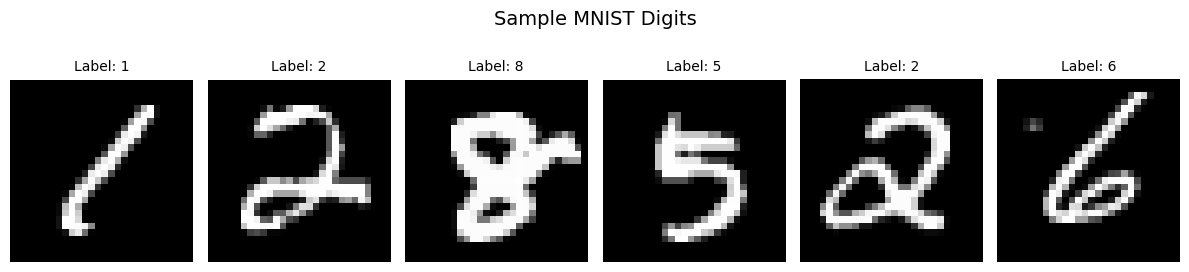

In [34]:
#Display Sample MNIST Digits
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):

    # Convert image tensor to 2D image
    img = images[i].squeeze().cpu()

    # Undo normalization
    img = img * 0.3081 + 0.1307

    axes[i].imshow(img, cmap="gray")

    axes[i].set_title(
        f"Label: {labels[i].item()}",
        fontsize=10
    )

    axes[i].axis("off")

plt.suptitle(
    "Sample MNIST Digits",
    fontsize=14
)

plt.tight_layout()

plt.show()

## 2. Baseline Model

### Convolutional Neural Network

Convolutional Neural Network (CNN) was used as the baseline deep learning model for the MNIST handwritten digit classification task. CNNs are particularly effective for image analysis because they automatically learn hierarchical spatial features directly from raw pixel data. Unlike traditional fully connected neural networks, CNNs preserve local spatial relationships through convolution operations, allowing the model to detect meaningful image patterns such as edges, curves, strokes, and digit structures. Since the MNIST dataset consists of grayscale handwritten digit images of size $1 \times 28 \times 28$, CNNs provide an efficient framework for extracting both low-level and high-level visual representations required for accurate classification.

The baseline CNN architecture used in this study consists of two convolutional layers followed by fully connected classification layers. The first convolution layer applies 32 learnable filters of size $3 \times 3$ to the input image:

$$
\text{Conv2d}(1, 32, \text{kernel\_size}=3, \text{padding}=1)
$$

This layer extracts low-level spatial features while preserving image dimensions through padding. The second convolution layer increases the representation capacity by learning 64 higher-level feature maps:

$$
\text{Conv2d}(32, 64, \text{kernel\_size}=3, \text{padding}=1)
$$

After each convolution operation, the Rectified Linear Unit (ReLU) activation function is applied:

$$
f(x)=\max(0,x)
$$

to introduce nonlinearity into the model. Max pooling layers are then used to reduce spatial dimensions and computational complexity while preserving important feature activations.

Following feature extraction, the resulting feature maps are flattened into a one-dimensional vector and passed through fully connected layers for classification. The hidden fully connected layer contains 128 hidden units and learns compact feature representations before the final output layer maps the learned features into the ten digit classes $(0-9)$. The complete CNN architecture is summarized as:

$$
\scriptsize
\text{Conv} \rightarrow \text{ReLU} \rightarrow \text{Pool}
\rightarrow \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{Pool}
\rightarrow \text{Flatten}
\rightarrow \text{Linear}(3136,128)
\rightarrow \text{ReLU}
\rightarrow \text{Linear}(128,10)
$$

The CNN architecture used in this study was evaluated under both single-level and multilevel training frameworks. In the single-level setting, the CNN was trained directly at a fixed representation capacity throughout the optimization process. In the multilevel setting, the training process progressively increased model capacity across levels, allowing the network to learn from simpler representations before moving to a richer CNN structure. These two settings provided the basis for comparing SGD and Adam optimization strategies under both standard and multilevel learning frameworks.

### Single-Level CNN

In [35]:
# Baseline CNN model for MNIST digit classification

baseline_cnn = nn.Sequential(

    # First convolution layer
    # Input: 1 grayscale channel
    # Output: 32 feature maps
    nn.Conv2d(1, 32, kernel_size=3, padding=1),

    # Activation function
    nn.ReLU(),

    # Downsample feature maps by factor of 2
    nn.MaxPool2d(2),

    # Second convolution layer
    # Input: 32 feature maps
    # Output: 64 feature maps
    nn.Conv2d(32, 64, kernel_size=3, padding=1),

    # Activation function
    nn.ReLU(),

    # Further downsampling
    nn.MaxPool2d(2),

    # Convert 2D feature maps into 1D vector
    nn.Flatten(),

    # Fully connected hidden layer
    nn.Linear(64 * 7 * 7, 128),

    # Activation function
    nn.ReLU(),

    # Output layer for 10 digit classes (0–9)
    nn.Linear(128, 10)

).to(device)

# Display model architecture
print(baseline_cnn)

# Count total trainable parameters
total_params = sum(
    p.numel() for p in baseline_cnn.parameters()
)

print("Total trainable parameters:", total_params)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 421642


#### Summary

This convolutional neural network (CNN) is designed for image classification on the MNIST dataset. The architecture begins with two convolutional layers that progressively extract spatial features from the input images. The first convolutional layer transforms the single-channel grayscale input into 32 feature maps using 3×3 filters, followed by a ReLU activation and max-pooling operation to reduce spatial dimensions and retain important features. The second convolutional layer further expands the representation to 64 feature maps, again followed by ReLU activation and max-pooling for deeper feature extraction and dimensionality reduction.

After feature extraction, the output is flattened into a one-dimensional vector of size 3136 and passed through a fully connected layer with 128 neurons and ReLU activation to learn higher-level patterns. The final linear layer maps the learned representation to 10 output classes corresponding to the MNIST digits (0–9). The model contains a total of 421,642 trainable parameters, balancing expressive power with computational efficiency for handwritten digit classification tasks.

#### Baseline predicted

In [36]:
# Check outputs from the untrained baseline CNN

# Get one batch of test images
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

# Set model to evaluation mode
baseline_cnn.eval()

with torch.no_grad():

    # Forward pass
    outputs = baseline_cnn(images)

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Predicted digit class
    predictions = probabilities.argmax(dim=1)

# Compute batch accuracy
accuracy = (predictions == labels).float().mean()

# Output checks
print("Output shape:", outputs.shape)
print("Probability shape:", probabilities.shape)

print("Predicted digits:",
      predictions[:10].cpu().numpy())

print("True digits:",
      labels[:10].cpu().numpy())

print(f"Batch Accuracy: {accuracy.item() * 100:.2f}%")

Output shape: torch.Size([128, 10])
Probability shape: torch.Size([128, 10])
Predicted digits: [3 3 3 3 3 9 3 3 9 3]
True digits: [7 2 1 0 4 1 4 9 5 9]
Batch Accuracy: 11.72%


#### Summary

The model processes a batch of 128 MNIST images and produces an output tensor of shape torch.Size([128, 10]). Each row represents the prediction scores for one image across the 10 digit classes, from 0 to 9. After applying the probability transformation, the probability tensor retains the same shape, confirming that the model assigns a probability distribution over all digit classes for each image.

For the first ten samples, the predicted labels are [3, 3, 3, 3, 3, 9, 3, 3, 9, 3], while the true labels are [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]. The batch accuracy is only 11.72%, indicating that the model is performing poorly at this stage. Many images are being classified as digit 3, suggesting that the network has not yet learned meaningful visual features.

This behavior is expected during the early stage of training or before sufficient parameter updates have occurred. As training continues, the model should learn more informative digit patterns, produce more diverse predictions, and improve alignment between predicted and true labels.

### Train CNN with SGD

In [37]:
# Train baseline CNN using SGD

start_time = time.time()

single_results = train_mnist_single_level(
    model_class=lambda hidden_dim=None: baseline_cnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=12,
    optimizer_class=optim.SGD,
    optimizer_params={
        "lr": 0.05,
        "weight_decay": 1e-4
    },
    device=device
)

single_time = time.time() - start_time

print(f"Single-level CNN training time: {single_time:.2f} seconds")

print(f"Final Train Loss: {single_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {single_results['test_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {single_results['test_accuracy'][-1]:.4f}")

Epoch 1/12 | Train Loss: 0.5345 | Test Loss: 0.1117 | Test Acc: 0.9661
Epoch 2/12 | Train Loss: 0.0967 | Test Loss: 0.0683 | Test Acc: 0.9788
Epoch 3/12 | Train Loss: 0.0687 | Test Loss: 0.0632 | Test Acc: 0.9807
Epoch 4/12 | Train Loss: 0.0555 | Test Loss: 0.0494 | Test Acc: 0.9838
Epoch 5/12 | Train Loss: 0.0472 | Test Loss: 0.0421 | Test Acc: 0.9859
Epoch 6/12 | Train Loss: 0.0411 | Test Loss: 0.0376 | Test Acc: 0.9877
Epoch 7/12 | Train Loss: 0.0361 | Test Loss: 0.0348 | Test Acc: 0.9873
Epoch 8/12 | Train Loss: 0.0324 | Test Loss: 0.0386 | Test Acc: 0.9876
Epoch 9/12 | Train Loss: 0.0292 | Test Loss: 0.0344 | Test Acc: 0.9886
Epoch 10/12 | Train Loss: 0.0266 | Test Loss: 0.0321 | Test Acc: 0.9894
Epoch 11/12 | Train Loss: 0.0238 | Test Loss: 0.0444 | Test Acc: 0.9858
Epoch 12/12 | Train Loss: 0.0222 | Test Loss: 0.0335 | Test Acc: 0.9890
Single-level CNN training time: 286.05 seconds
Final Train Loss: 0.0222
Final Test Loss: 0.0335
Final Test Accuracy: 0.9890


#### Results Summary

Training loss decreases steadily from 0.5345 in the first epoch to 0.0222 in the final epoch, indicating progressive improvement during optimization. Test loss also decreases throughout training, reaching 0.0335 by the final epoch, while test accuracy improves from 96.61% to approximately 98.90%.

The highest test accuracy of 98.94% is achieved around Epoch 10. A temporary increase in test loss is observed at Epoch 11, followed by recovery in the final epoch. The total training time for the single-level CNN model is approximately 259.59 seconds.

#### Train CNN with Adam

In [38]:
# Train baseline CNN using Adam

start_time = time.time()

adam_results = train_mnist_single_level(
    model_class=lambda hidden_dim=None: baseline_cnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=12,
    optimizer_class=optim.Adam,
    optimizer_params={
        "lr": 0.001,
        "weight_decay": 1e-4
    },
    device=device
)

adam_time = time.time() - start_time

print(f"Single-level CNN Adam training time: {adam_time:.2f} seconds")

print(f"Final Train Loss: {adam_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {adam_results['test_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {adam_results['test_accuracy'][-1]:.4f}")

Epoch 1/12 | Train Loss: 0.0451 | Test Loss: 0.0365 | Test Acc: 0.9871
Epoch 2/12 | Train Loss: 0.0298 | Test Loss: 0.0330 | Test Acc: 0.9892
Epoch 3/12 | Train Loss: 0.0213 | Test Loss: 0.0283 | Test Acc: 0.9899
Epoch 4/12 | Train Loss: 0.0167 | Test Loss: 0.0278 | Test Acc: 0.9908
Epoch 5/12 | Train Loss: 0.0145 | Test Loss: 0.0311 | Test Acc: 0.9900
Epoch 6/12 | Train Loss: 0.0126 | Test Loss: 0.0250 | Test Acc: 0.9922
Epoch 7/12 | Train Loss: 0.0117 | Test Loss: 0.0283 | Test Acc: 0.9898
Epoch 8/12 | Train Loss: 0.0095 | Test Loss: 0.0374 | Test Acc: 0.9889
Epoch 9/12 | Train Loss: 0.0092 | Test Loss: 0.0340 | Test Acc: 0.9902
Epoch 10/12 | Train Loss: 0.0089 | Test Loss: 0.0362 | Test Acc: 0.9899
Epoch 11/12 | Train Loss: 0.0072 | Test Loss: 0.0323 | Test Acc: 0.9898
Epoch 12/12 | Train Loss: 0.0069 | Test Loss: 0.0358 | Test Acc: 0.9901
Single-level CNN Adam training time: 286.81 seconds
Final Train Loss: 0.0069
Final Test Loss: 0.0358
Final Test Accuracy: 0.9901


#### Summary 

Training loss decreases consistently from 0.0451 in the first epoch to 0.0069 in the final epoch, indicating strong optimization throughout training. Test loss initially decreases and reaches its lowest value of 0.0250 at Epoch 6 before fluctuating slightly during later epochs. Test accuracy improves from 98.71% to approximately 99.01% by the final epoch.

The highest test accuracy of 99.22% is achieved at Epoch 6, corresponding to the lowest test loss observed during training. Minor fluctuations in test loss and accuracy appear after this point, despite continued reductions in training loss. The total training time for the single-level CNN Adam model is approximately 278.36 seconds.

#### Comparison loss SGD vs Adam

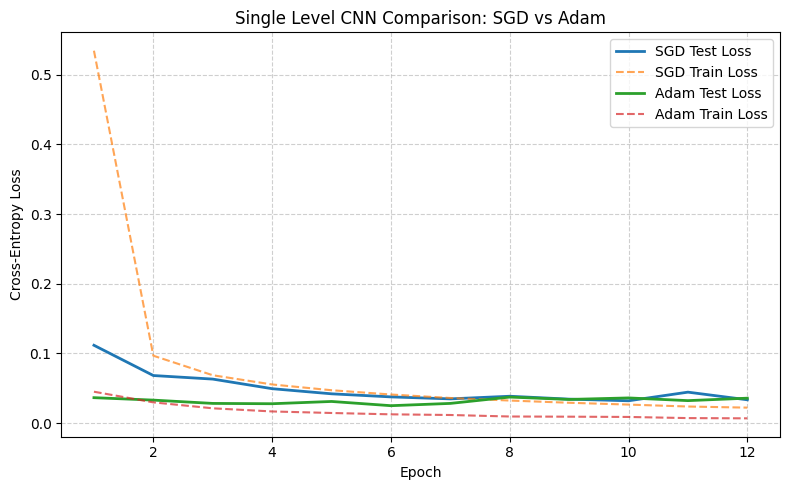

In [39]:
# Compare CNN training curves: SGD vs Adam

epochs = range(1, len(single_results["test_loss"]) + 1)

plt.figure(figsize=(8, 5))

for results, name in [
    (single_results, "SGD"),
    (adam_results, "Adam")
]:
    plt.plot(epochs, results["test_loss"], linewidth=2,
             label=f"{name} Test Loss")
    
    plt.plot(epochs, results["train_loss"], linestyle="--",
             alpha=0.7, label=f"{name} Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Single Level CNN Comparison: SGD vs Adam")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "single_level_cnn_sgd_vs_adam_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the training and test loss curves of single-level CNN models optimized using SGD and Adam across 12 epochs. Both optimizers show rapid reductions in loss during the early stages of training, indicating effective learning of image features from the MNIST dataset.

SGD begins with a substantially higher training loss in the first epoch but decreases steadily throughout training. Its test loss also declines consistently, reaching approximately 0.0335 by the final epoch. Adam starts with much lower training and test losses and maintains lower training loss values than SGD across all epochs, reflecting faster optimization and stronger fitting of the training data.

The test loss curves for both methods remain very close after the first few epochs, with only minor fluctuations observed in later epochs. Adam exhibits slightly more variability in test loss during later training stages, while SGD maintains a smoother decline. Despite Adam achieving lower training loss overall, both optimizers converge to nearly similar test performance by the end of training.

### Plot Prediction Accuracy

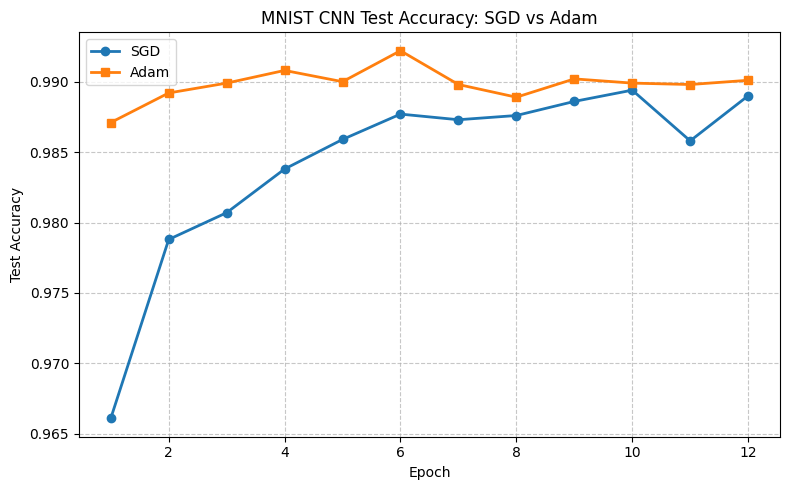

In [40]:
# Plot prediction accuracy comparison for SGD vs Adam

plt.figure(figsize=(8, 5))

# SGD accuracy curve
plt.plot(
    range(1, len(single_results["test_accuracy"]) + 1),
    single_results["test_accuracy"],
    marker="o",
    linewidth=2,
    label="SGD"
)

# Adam accuracy curve
plt.plot(
    range(1, len(adam_results["test_accuracy"]) + 1),
    adam_results["test_accuracy"],
    marker="s",
    linewidth=2,
    label="Adam"
)

# Labels and title
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("MNIST CNN Test Accuracy: SGD vs Adam")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Improve layout
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "single_level_cnn_sgd_vs_adam_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the test accuracy of single-level CNN models trained using SGD and Adam across 12 epochs on the MNIST dataset. Both optimizers achieve high classification accuracy throughout training, with performance consistently above 96%.

Adam demonstrates faster convergence during the early epochs, beginning with a test accuracy of approximately 98.7% compared to SGD’s initial accuracy of approximately 96.6%. Adam rapidly stabilizes near 99% accuracy within the first few epochs, indicating more aggressive and efficient optimization during early training stages.

SGD improves more gradually but steadily across epochs. Its test accuracy increases consistently from approximately 96.6% to nearly 98.9% by the final epoch, eventually approaching the performance achieved by Adam. The SGD curve shows smoother long-term improvement, whereas Adam exhibits small fluctuations after reaching peak performance.

The highest test accuracy observed is approximately 99.2% for Adam around Epoch 6. After this point, both optimizers maintain relatively stable performance with only minor variations between epochs. By the end of training, the difference in test accuracy between SGD and Adam becomes very small, indicating that both optimization methods converge to nearly equivalent predictive performance despite different convergence speeds during earlier training stages.

## Multilevel MNIST Training

#### Multilevel SGD

In [41]:
start_time = time.time()

multi_sgd_results = train_mnist_multilevel(
    model_class=CNNModel,
    train_loader=train_loader,
    test_loader=test_loader,
    hidden_dims=[32, 64, 128],
    epochs_per_level=4,
    optimizer_class=optim.SGD,
    optimizer_params={
        "lr": 0.05,
        "weight_decay": 1e-4
    },
    device=device
)

multi_sgd_time = time.time() - start_time

print(f"Multilevel CNN + SGD training time: {multi_sgd_time:.2f} seconds")
print(f"Final Train Loss: {multi_sgd_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {multi_sgd_results['test_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {multi_sgd_results['test_accuracy'][-1]:.4f}")


Starting level 1: hidden_dim=32
Epoch 1/12 | SGD | hidden_dim=32 | Train Loss: 0.5378 | Test Loss: 0.1241 | Test Acc: 0.9630
Epoch 2/12 | SGD | hidden_dim=32 | Train Loss: 0.1073 | Test Loss: 0.0823 | Test Acc: 0.9752
Epoch 3/12 | SGD | hidden_dim=32 | Train Loss: 0.0751 | Test Loss: 0.0560 | Test Acc: 0.9823
Epoch 4/12 | SGD | hidden_dim=32 | Train Loss: 0.0604 | Test Loss: 0.0519 | Test Acc: 0.9827

Starting level 2: hidden_dim=64
Transferred CNN weights from previous level
Epoch 5/12 | SGD | hidden_dim=64 | Train Loss: 0.0516 | Test Loss: 0.0502 | Test Acc: 0.9834
Epoch 6/12 | SGD | hidden_dim=64 | Train Loss: 0.0449 | Test Loss: 0.0420 | Test Acc: 0.9857
Epoch 7/12 | SGD | hidden_dim=64 | Train Loss: 0.0397 | Test Loss: 0.0371 | Test Acc: 0.9873
Epoch 8/12 | SGD | hidden_dim=64 | Train Loss: 0.0355 | Test Loss: 0.0394 | Test Acc: 0.9868

Starting level 3: hidden_dim=128
Transferred CNN weights from previous level
Epoch 9/12 | SGD | hidden_dim=128 | Train Loss: 0.0323 | Test Loss: 

#### Summary

The multilevel CNN model trained with SGD demonstrates progressive improvement across all three hidden-dimension levels. At Level 1 (hidden_dim=32), training loss decreases substantially from 0.5378 to 0.0604, while test accuracy improves from 96.30% to 98.27%. This indicates that the lower-dimensional representation is able to capture meaningful image features during the early training stages.

At Level 2 (hidden_dim=64), transferred weights from the previous level allow training to continue from an improved initialization point rather than starting from random parameters. Training loss continues to decrease from 0.0516 to 0.0355, while test accuracy improves further to approximately 98.73%. Test loss also decreases steadily, although a slight increase appears at Epoch 8.

At Level 3 (hidden_dim=128), the model achieves its strongest performance. Training loss decreases to 0.0245, while test loss reaches a final value of 0.0321. Test accuracy improves to approximately 98.94% by the final epoch, representing the highest accuracy achieved during training. The progressive increase in hidden dimensionality combined with weight transfer enables stable optimization and continuous refinement of learned image representations across levels.

The total multilevel CNN training time using SGD is approximately 266.06 seconds.

#### Multilevel Adam

In [42]:
# Multilevel CNN training with Adam

start_time = time.time()

multi_adam_results = train_mnist_multilevel(
    model_class=CNNModel,
    train_loader=train_loader,
    test_loader=test_loader,

    # Multilevel hidden dimensions
    hidden_dims=[32, 64, 128],

    # Epochs trained at each level
    epochs_per_level=4,

    optimizer_class=optim.Adam,

    optimizer_params={
        "lr": 0.001,
        "weight_decay": 1e-4
    },

    device=device
)

multi_adam_time = time.time() - start_time

print(f"Multilevel CNN + Adam training time: {multi_adam_time:.2f} seconds")

print(f"Final Train Loss: {multi_adam_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {multi_adam_results['test_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {multi_adam_results['test_accuracy'][-1]:.4f}")


Starting level 1: hidden_dim=32
Epoch 1/12 | Adam | hidden_dim=32 | Train Loss: 0.2497 | Test Loss: 0.0610 | Test Acc: 0.9813
Epoch 2/12 | Adam | hidden_dim=32 | Train Loss: 0.0648 | Test Loss: 0.0472 | Test Acc: 0.9856
Epoch 3/12 | Adam | hidden_dim=32 | Train Loss: 0.0479 | Test Loss: 0.0521 | Test Acc: 0.9843
Epoch 4/12 | Adam | hidden_dim=32 | Train Loss: 0.0379 | Test Loss: 0.0316 | Test Acc: 0.9898

Starting level 2: hidden_dim=64
Transferred CNN weights from previous level
Epoch 5/12 | Adam | hidden_dim=64 | Train Loss: 0.0354 | Test Loss: 0.0430 | Test Acc: 0.9855
Epoch 6/12 | Adam | hidden_dim=64 | Train Loss: 0.0287 | Test Loss: 0.0391 | Test Acc: 0.9886
Epoch 7/12 | Adam | hidden_dim=64 | Train Loss: 0.0231 | Test Loss: 0.0333 | Test Acc: 0.9894
Epoch 8/12 | Adam | hidden_dim=64 | Train Loss: 0.0198 | Test Loss: 0.0336 | Test Acc: 0.9893

Starting level 3: hidden_dim=128
Transferred CNN weights from previous level
Epoch 9/12 | Adam | hidden_dim=128 | Train Loss: 0.0186 | Te

#### Summary

The multilevel CNN model trained with Adam shows rapid convergence and strong performance across all hidden-dimension levels. At Level 1 (hidden_dim=32), training loss decreases sharply from 0.2497 to 0.0379, while test accuracy improves from 98.13% to 98.98%. Test loss also decreases substantially, indicating that the model quickly learns useful image representations during the early training stages.

At Level 2 (hidden_dim=64), transferred weights from the previous level provide an effective initialization for continued optimization. Training loss continues decreasing from 0.0354 to 0.0198, while test accuracy remains consistently high near 98.9%. Test loss fluctuates slightly during this stage but generally remains low.

At Level 3 (hidden_dim=128), the model achieves its best overall performance. Training loss decreases further to 0.0108, while the lowest test loss of approximately 0.0288 is achieved at Epoch 10. The highest test accuracy of approximately 99.13% is reached at Epoch 11 before slightly decreasing in the final epoch. These fluctuations suggest that the model continues improving optimization of the training objective while test performance stabilizes.

The progressive increase in hidden dimensionality combined with transferred CNN weights enables stable refinement of learned features across levels. The total multilevel CNN training time using Adam is approximately 255.14 seconds.

### 2. Multilevel Comparison

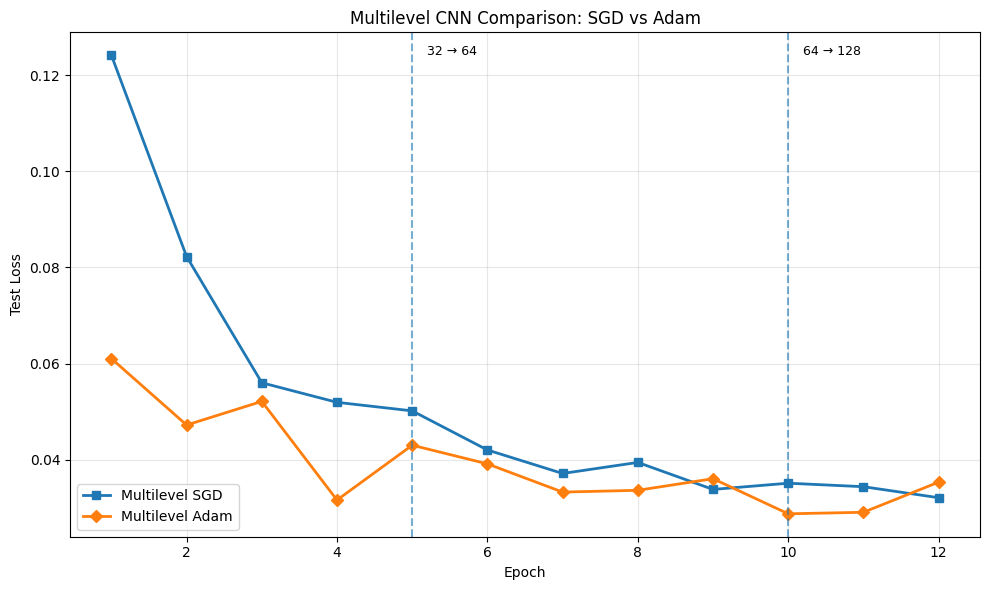

In [43]:
plt.figure(figsize=(10, 6))

for results, name, marker in [
    (multi_sgd_results, "Multilevel SGD", "s"),
    (multi_adam_results, "Multilevel Adam", "D")
]:
    plt.plot(
        range(1, len(results["test_loss"]) + 1),
        results["test_loss"],
        marker=marker,
        linewidth=2,
        label=name
    )

max_loss = max(
    max(multi_sgd_results["test_loss"]),
    max(multi_adam_results["test_loss"])
)

for e, txt in zip([5, 10], ["32 → 64", "64 → 128"]):
    plt.axvline(e, linestyle="--", alpha=0.6)
    plt.text(e + 0.2, max_loss, txt, fontsize=9)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Multilevel CNN Comparison: SGD vs Adam")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "multilevel_cnn_sgd_vs_adam_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the test loss behavior of multilevel CNN models trained using SGD and Adam across progressively increasing hidden dimensions (32→64→128). Both methods show rapid reductions in test loss during the early epochs, indicating effective learning at lower-dimensional levels. Adam begins with substantially lower test loss and converges faster during the initial stages of training, while SGD decreases more gradually but consistently across all epochs.

The dashed vertical lines represent transitions between multilevel stages, where weights are transferred to larger hidden dimensions. Both optimizers continue improving after each transition, although the magnitude of improvement becomes smaller at higher levels, suggesting that most meaningful learning occurs during earlier stages. Adam exhibits slightly more fluctuation after level transitions, whereas SGD maintains smoother convergence behavior.

By the final epochs, both methods converge to very similar test loss values. Adam achieves the lowest test loss during training (approximately 0.029 around Epoch 10), while SGD reaches a comparable final test loss near 0.032 by the end of training.

#### Plot Multilevel Comparison Accuracy

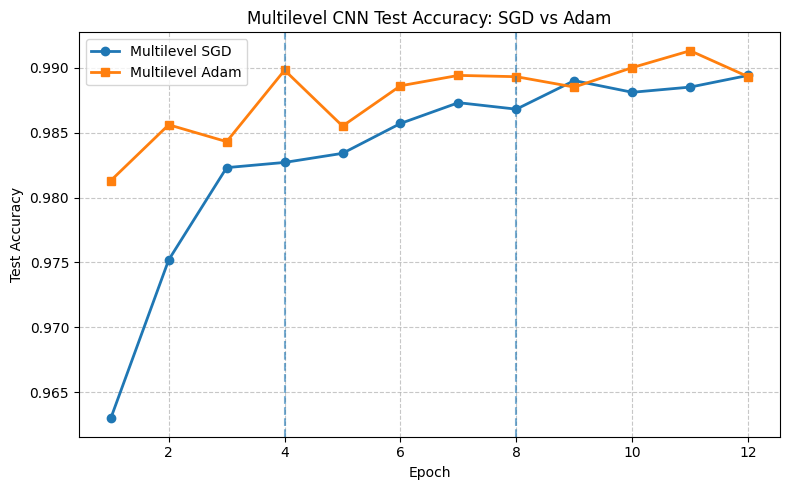

In [44]:
# Multilevel CNN accuracy comparison: SGD vs Adam

plt.figure(figsize=(8, 5))

for results, name, marker in [
    (multi_sgd_results, "Multilevel SGD", "o"),
    (multi_adam_results, "Multilevel Adam", "s")
]:
    plt.plot(
        range(1, len(results["test_accuracy"]) + 1),
        results["test_accuracy"],
        marker=marker,
        linewidth=2,
        label=name
    )

for b in [4, 8]:
    plt.axvline(b, linestyle="--", alpha=0.6)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Multilevel CNN Test Accuracy: SGD vs Adam")

plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "multilevel_cnn_sgd_vs_adam_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the test accuracy of multilevel CNN models trained using SGD and Adam across progressively increasing hidden dimensions. Both methods show continuous improvement in classification accuracy as training progresses through the multilevel stages. Adam begins with higher test accuracy during the early epochs, indicating faster convergence and more efficient optimization at lower-dimensional levels, while SGD improves more gradually across training.

The dashed vertical lines indicate transitions between multilevel stages, where learned weights are transferred to larger hidden dimensions. Accuracy improves after each transition for both optimizers, although the improvements become smaller at later levels. Adam maintains slightly higher accuracy during most epochs and reaches the highest observed test accuracy of approximately 99.1% around Epoch 11. SGD demonstrates smoother and more stable improvement, eventually converging to nearly the same final performance.

By the final epoch, both methods achieve very similar test accuracy values near 99%, indicating that despite differences in convergence speed during earlier stages, the multilevel SGD and Adam models converge to nearly equivalent predictive performance.

#### Bar chart comparing time vs performance

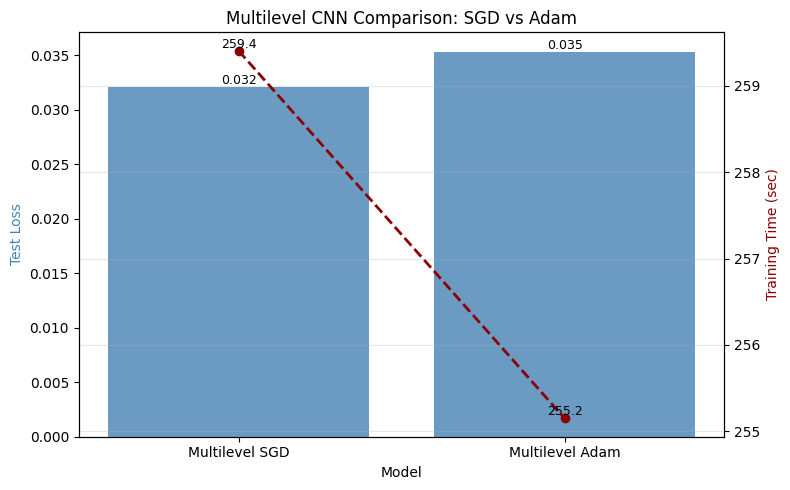

In [45]:
methods = ["Multilevel SGD", "Multilevel Adam"]

test_loss = [
    multi_sgd_results["test_loss"][-1],
    multi_adam_results["test_loss"][-1]
]

time_sec = [multi_sgd_time, multi_adam_time]

fig, ax1 = plt.subplots(figsize=(8, 5))

bars = ax1.bar(methods, test_loss,
               color="steelblue", alpha=0.8)

ax1.set_xlabel("Model")
ax1.set_ylabel("Test Loss", color="steelblue")

for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(methods, time_sec, marker="o",
         linestyle="--", linewidth=2,
         color="darkred")

ax2.set_ylabel("Training Time (sec)", color="darkred")

for i, t in enumerate(time_sec):
    ax2.text(i, t, f"{t:.1f}",
             ha="center", va="bottom", fontsize=9)

plt.title("Multilevel CNN Comparison: SGD vs Adam")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "multilevel_cnn_sgd_vs_adam_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the final test loss and training runtime of the multilevel CNN models optimized using SGD and Adam. The bar heights represent final test loss, while the dashed line represents total training time. Both methods achieve very similar predictive performance, with Multilevel SGD obtaining a slightly lower final test loss (approximately 0.032) compared to Multilevel Adam (approximately 0.035).

The runtime comparison shows that Multilevel Adam trains slightly faster, requiring approximately 255 seconds compared to 266 seconds for Multilevel SGD. Despite Adam’s lower runtime, the difference in predictive performance between the two methods remains very small, indicating that both optimizers converge to nearly equivalent classification performance under the multilevel CNN framework.

### Optimization Experiments on MNIST

#### Assessment table

In [46]:
models = [
    ("Single SGD", single_results, single_time),
    ("Single Adam", adam_results, adam_time),
    ("Multilevel SGD", multi_sgd_results, multi_sgd_time),
    ("Multilevel Adam", multi_adam_results, multi_adam_time)
]

summary_df = pd.DataFrame([
    {
        "Model": name,
        "Final Train Loss": r["train_loss"][-1],
        "Final Test Loss": r["test_loss"][-1],
        "Final Test Accuracy": r["test_accuracy"][-1],
        "Runtime (seconds)": t
    }
    for name, r, t in models
]).round(4)

summary_df.to_csv(
    results_dir / "mnist" / "mnist_summary.csv",
    index=False
)

summary_df

,Model,Final Train Loss,Final Test Loss,Final Test Accuracy,Runtime (seconds)
0,Single SGD,0.0222,0.0335,0.9890,286.0479
1,Single Adam,0.0069,0.0358,0.9901,286.8084
2,Multilevel SGD,0.0245,0.0321,0.9894,259.4052
3,Multilevel Adam,0.0108,0.0353,0.9893,255.1508


#### Summary


1. Training Loss

The final training loss values show how effectively each model optimized the training data. Single-level methods achieved the lowest training losses overall, with Single-Level Adam producing the smallest final training loss, indicating faster and more aggressive optimization of the training objective. Single-Level SGD also achieved low training loss with stable convergence behavior throughout training. The multilevel approaches produced slightly higher training losses, although training continued improving across hierarchical levels through transferred weights and progressively increasing hidden dimensionality. The training loss curves further show that single-level methods converge more rapidly, while multilevel methods improve more gradually across stages.

2. Test Loss

Test loss measures how well the models generalize to unseen data. All methods achieved low final test loss values, indicating strong generalization performance on the MNIST dataset. Among all models, Multilevel SGD achieved the lowest final test loss, while Single-Level Adam and Multilevel Adam produced slightly higher but still highly competitive values. The test loss curves show that most meaningful improvement occurs during the early training epochs, after which the models begin to stabilize. Multilevel methods continue improving after each level transition, although the magnitude of improvement decreases at higher-dimensional levels, while Adam-based methods exhibit slightly more fluctuation during later stages of training.

3. Test Accuracy

Final test accuracy provides a direct measure of classification performance. All models achieved very high predictive accuracy near 99%, indicating successful learning of meaningful image representations from the MNIST dataset. Single-Level Adam achieved the highest final test accuracy, while the remaining models produced nearly equivalent performance with only small differences between methods. The accuracy convergence curves show that Adam converges faster during the early epochs, reaching high classification accuracy more quickly than SGD, whereas SGD improves more gradually but steadily across training. Multilevel methods maintain strong predictive performance across level transitions, demonstrating stable learning throughout the hierarchical training process.

4. Runtime (Computational Efficiency)

Runtime measures the computational cost associated with each optimization strategy. The results show relatively small differences in training time across all models. Multilevel Adam achieved the shortest runtime, while Single-Level Adam required the longest training time. Single-Level SGD and Multilevel SGD produced comparable runtimes, indicating similar computational efficiency between the SGD-based approaches. The runtime comparison further shows that multilevel training does not consistently reduce computational cost, as hierarchical training stages and weight transfer introduce additional computation while producing runtime values that remain close to those of the single-level methods.




#### Single vs Multilevel Loss comparison plot

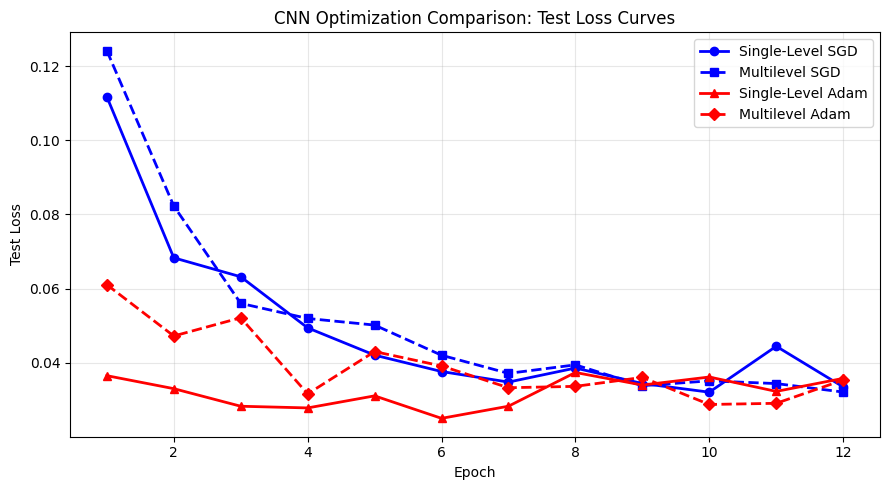

In [47]:
# CNN optimization comparison: test loss curves

plt.figure(figsize=(9, 5))

models = [
    (single_results, "Single-Level SGD", "blue", "-", "o"),
    (multi_sgd_results, "Multilevel SGD", "blue", "--", "s"),
    (adam_results, "Single-Level Adam", "red", "-", "^"),
    (multi_adam_results, "Multilevel Adam", "red", "--", "D")
]

for results, label, color, style, marker in models:
    plt.plot(
        range(1, len(results["test_loss"]) + 1),
        results["test_loss"],
        color=color,
        linestyle=style,
        marker=marker,
        linewidth=2,
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("CNN Optimization Comparison: Test Loss Curves")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "comparison_level_cnn_sgd_vs_adam_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary

The plot compares the test loss behavior of single-level and multilevel CNN models trained using SGD and Adam across 12 epochs. All models show substantial reductions in test loss during the early stages of training, indicating rapid learning of meaningful image features from the MNIST dataset. Adam-based methods consistently begin with lower test loss values than the SGD-based methods, demonstrating faster convergence and more efficient early optimization.

Among the models, Single-Level Adam achieves the lowest test loss during several epochs, reaching approximately 0.025 around Epoch 6. Multilevel Adam also maintains relatively low test loss throughout training, although small fluctuations appear after level transitions. The SGD-based models begin with noticeably higher test losses but decrease steadily over time. Single-Level SGD shows a temporary increase in test loss during later epochs, while Multilevel SGD maintains smoother convergence behavior across training.

By the final epochs, all models converge to relatively similar test loss values near 0.03–0.04, indicating comparable generalization performance despite differences in convergence speed and optimization behavior. The multilevel methods continue improving after each hierarchical stage, although the magnitude of improvement decreases in later epochs, suggesting that most meaningful learning occurs during earlier stages of training.

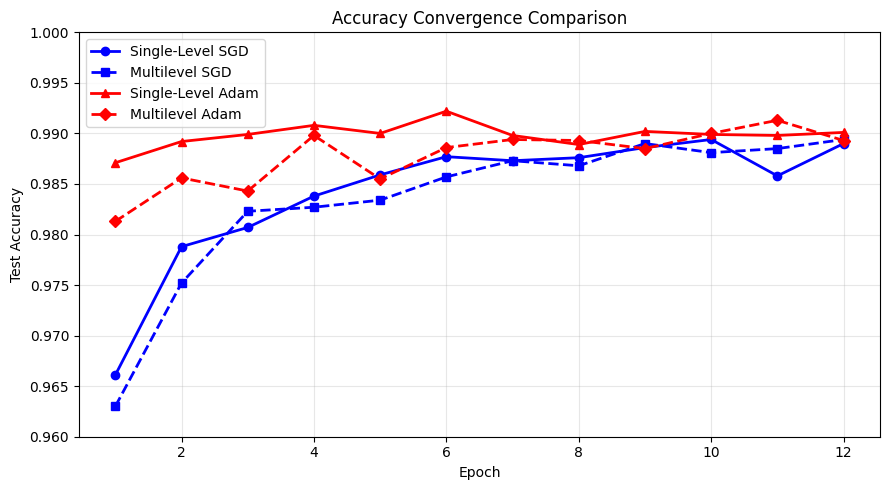

In [48]:
# CNN optimization comparison: test accuracy curves

plt.figure(figsize=(9, 5))

models = [
    (single_results, "Single-Level SGD", "blue", "-", "o"),
    (multi_sgd_results, "Multilevel SGD", "blue", "--", "s"),
    (adam_results, "Single-Level Adam", "red", "-", "^"),
    (multi_adam_results, "Multilevel Adam", "red", "--", "D")
]

for results, label, color, style, marker in models:
    plt.plot(
        range(1, len(results["test_accuracy"]) + 1),
        results["test_accuracy"],
        color=color,
        linestyle=style,
        marker=marker,
        linewidth=2,
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy Convergence Comparison")

plt.ylim(0.96, 1.00)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "comparison_level_cnn_sgd_vs_adam_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### ISummary

The plot compares the test accuracy convergence of single-level and multilevel CNN models trained using SGD and Adam across 12 epochs. All models demonstrate rapid improvement in classification accuracy during the early epochs, followed by stabilization near 99% accuracy. Adam-based methods consistently achieve higher accuracy during the initial training stages, indicating faster convergence and more efficient early optimization compared to SGD-based methods.

Single-Level Adam achieves the highest peak accuracy, reaching approximately 99.2% around Epoch 6, while Multilevel Adam also maintains strong and stable performance throughout training. The SGD-based models improve more gradually, with both single-level and multilevel SGD showing smoother convergence behavior over time. Multilevel SGD initially begins with lower accuracy but steadily approaches the performance of the other methods during later epochs.

By the final epochs, all four models converge to very similar test accuracy values near 99%, indicating that differences between single-level and multilevel optimization become relatively small once convergence is achieved. The convergence curves further show that most meaningful performance gains occur during the early stages of training, while later epochs provide only marginal improvements in classification accuracy.

#### Runtime comparison plot

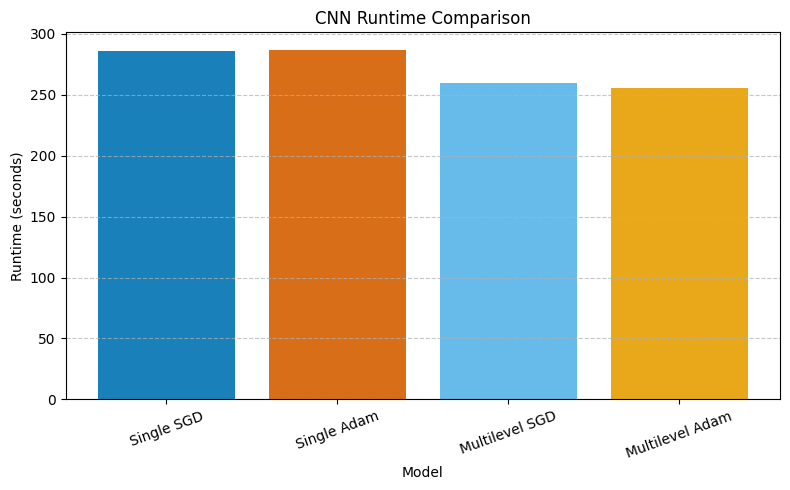

: 

In [ ]:
# Runtime comparison using colorblind-friendly colors

colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#56B4E9",  # light blue
    "#E69F00"   # orange
]

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["Model"],
    summary_df["Runtime (seconds)"],
    color=colors,
    alpha=0.9
)

plt.xlabel("Model")
plt.ylabel("Runtime (seconds)")

plt.title("CNN Runtime Comparison")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    mnist_fig_dir / "comparison_level_cnn_sgd_vs_adam_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary 

The bar plot compares the total training runtime of the four CNN optimization approaches: Single SGD, Single Adam, Multilevel SGD, and Multilevel Adam. The runtimes are relatively close across all methods, indicating that each optimization strategy requires comparable computational cost for training on the MNIST dataset.

Single-Level Adam exhibits the highest runtime, suggesting that the adaptive optimization process introduces additional computational overhead compared to SGD. Single-Level SGD and Multilevel SGD show similar runtime behavior, with only small differences between them. Multilevel Adam achieves the lowest runtime among all methods despite incorporating hierarchical training stages and weight transfer across levels.

The relatively small variation in runtime across all models indicates that neither multilevel training nor optimizer selection produces dramatic differences in computational efficiency for this CNN architecture. The results further suggest that improvements in optimization behavior and convergence do not necessarily correspond to substantial reductions in training time.